# NB_01 — Evaluación Prequencial: IEEE-CIS Fraud Detection

## Objetivo

Evaluar si las estrategias de reentrenamiento adaptativo (SLIDING_WINDOW, DECAY, DUAL_MODEL)
presentan una mejora significativa y consistente frente a ALL_HISTORY bajo escenarios de
dinámica temporal y delay de etiquetas.

## Diseño experimental

| Parámetro | Valor |
|-----------|-------|
| Dataset | IEEE-CIS Fraud Detection |
| Modelo base | LightGBM (hiperparámetros optimizados con Optuna) |
| Protocolo | Prequencial (evaluate-then-train) |
| Período temporal | Semana (`TransactionDT // (7×86400)`) |
| Warm-up | Semanas 0–11 (12 semanas) |
| Evaluación | Semanas 12–25 (14 períodos) |
| Estrategias | STATIC, ALL_HISTORY, SLIDING_WINDOW, DECAY, DUAL_MODEL |
| Delays | [0, 1, 2, 4] semanas |
| Métrica principal | AUC-PR |
| Métricas soporte | AUC-ROC, Precision@1%, Recall@1%, Lift@1% |

## Protocolo de actualización

Para cada período de evaluación `n` con delay `d`:
1. Predecir período `n` con el modelo actual
2. Calcular métricas
3. Calcular `available = n - d`
4. Actualizar modelo **solo si** `available >= WARMUP_END + 1` (datos nuevos post warm-up)

## Estructura

- **Parte 1**: Configuración y carga de datos
- **Parte 2**: Estructura temporal y preprocesamiento
- **Parte 3**: Optimización de hiperparámetros (Optuna)
- **Parte 4**: Protocolo prequencial
- **Parte 5**: Resumen y visualizaciones per-dataset

---
## Parte 1 — Configuración y carga de datos

In [1]:
# =============================================================================
# 1.1 Imports y configuración del entorno
# =============================================================================
import os
import json
import time
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import optuna
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

warnings.filterwarnings('ignore', category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)

print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Versiones: lightgbm={lgb.__version__}, optuna={optuna.__version__}, "
      f"pandas={pd.__version__}, numpy={np.__version__}")

Fecha de ejecución: 2026-06-01 21:29:55
Versiones: lightgbm=4.6.0, optuna=4.7.0, pandas=2.3.3, numpy=1.26.4


In [2]:
# =============================================================================
# 1.2 Configuración del experimento
# =============================================================================

# --- Dataset ---
DATASET_NAME = 'IEEE_CIS'
TARGET_COL   = 'isFraud'
PERIOD_COL   = 'Week'

# --- Rutas ---
BASE_DIR    = r'./'
DATA_DIR    = os.path.join(BASE_DIR, 'ieee-fraud-detection')
RESULTS_DIR = os.path.join(BASE_DIR, 'results', 'ieee_cis')
os.makedirs(RESULTS_DIR, exist_ok=True)

# --- Estructura temporal ---
WARMUP_WEEKS = list(range(0, 12))     # Semanas 0-11: entrenamiento inicial
EVAL_WEEKS   = list(range(12, 26))    # Semanas 12-25: evaluación prequencial
WARMUP_END   = WARMUP_WEEKS[-1]       # = 11

# --- Estrategias ---
STRATEGIES = ['STATIC', 'ALL_HISTORY', 'SLIDING_WINDOW', 'DECAY', 'DUAL_MODEL']

# --- Parámetros de estrategias ---
WINDOW_SIZE  = 8       # Semanas para SLIDING_WINDOW
FAST_WINDOW  = 2       # Semanas para modelo rápido en DUAL_MODEL
DECAY_FACTOR = 0.9     # Factor de decaimiento exponencial
BLEND_SLOW   = 0.6     # Peso del modelo lento en DUAL_MODEL
BLEND_FAST   = 0.4     # Peso del modelo rápido en DUAL_MODEL

# --- Delays (en semanas) ---
DELAY_SCENARIOS = [0, 1, 2, 4]   # Equivale a 0, 7, 14, 28 días

# --- Umbrales de filtrado de features ---
MISSING_THRESHOLD     = 0.90
CORRELATION_THRESHOLD = 0.95
MAX_CARDINALITY       = 80

# --- Optuna ---
N_OPTUNA_TRIALS    = 100
OPTUNA_TRAIN_WEEKS = list(range(0, 9))     # Semanas 0-8
OPTUNA_VAL_WEEKS   = list(range(9, 12))    # Semanas 9-11

print("=" * 70)
print(f"EXPERIMENTO: {DATASET_NAME}")
print("=" * 70)
print(f"  Warm-up:      semanas {WARMUP_WEEKS[0]}–{WARMUP_END} ({len(WARMUP_WEEKS)} períodos)")
print(f"  Evaluación:   semanas {EVAL_WEEKS[0]}–{EVAL_WEEKS[-1]} ({len(EVAL_WEEKS)} períodos)")
print(f"  Estrategias:  {STRATEGIES}")
print(f"  Delays (wk):  {DELAY_SCENARIOS}")
print(f"  WINDOW_SIZE:  {WINDOW_SIZE}")
print(f"  DECAY_FACTOR: {DECAY_FACTOR}")
print(f"  DUAL_MODEL:   blend={BLEND_SLOW}/{BLEND_FAST}, fast_window={FAST_WINDOW}")
print(f"  Optuna:       {N_OPTUNA_TRIALS} trials")

EXPERIMENTO: IEEE_CIS
  Warm-up:      semanas 0–11 (12 períodos)
  Evaluación:   semanas 12–25 (14 períodos)
  Estrategias:  ['STATIC', 'ALL_HISTORY', 'SLIDING_WINDOW', 'DECAY', 'DUAL_MODEL']
  Delays (wk):  [0, 1, 2, 4]
  WINDOW_SIZE:  8
  DECAY_FACTOR: 0.9
  DUAL_MODEL:   blend=0.6/0.4, fast_window=2
  Optuna:       100 trials


In [3]:
# =============================================================================
# 1.3 Carga de datos
# =============================================================================

print("Cargando train_transaction.csv...")
df_trans = pd.read_csv(os.path.join(DATA_DIR, 'train_transaction.csv'))
print(f"  Transacciones: {df_trans.shape}")

print("Cargando train_identity.csv...")
df_id = pd.read_csv(os.path.join(DATA_DIR, 'train_identity.csv'))
print(f"  Identidad: {df_id.shape}")

print("Merge por TransactionID...")
df = df_trans.merge(df_id, on='TransactionID', how='left')
print(f"  Dataset combinado: {df.shape}")
print(f"  Tasa de fraude: {df[TARGET_COL].mean():.4f} ({df[TARGET_COL].sum():,} fraudes)")

del df_trans, df_id

Cargando train_transaction.csv...
  Transacciones: (590540, 394)
Cargando train_identity.csv...
  Identidad: (144233, 41)
Merge por TransactionID...
  Dataset combinado: (590540, 434)
  Tasa de fraude: 0.0350 (20,663 fraudes)


In [4]:
# =============================================================================
# 1.4 Feature engineering temporal
# =============================================================================

SECONDS_PER_DAY  = 86400
SECONDS_PER_WEEK = 7 * SECONDS_PER_DAY

# Período principal (granularidad del experimento)
df['Week']      = (df['TransactionDT'] // SECONDS_PER_WEEK).astype(int)
df['Day']       = (df['TransactionDT'] // SECONDS_PER_DAY).astype(int)
df['Hour']      = ((df['TransactionDT'] % SECONDS_PER_DAY) // 3600).astype(int)
df['DayOfWeek'] = (df['Day'] % 7).astype(int)

# Log-transformación del monto
df['log_TransactionAmt'] = np.log1p(df['TransactionAmt'])

print("Features temporales creadas:")
print(f"  Week:      {df['Week'].nunique()} valores únicos (rango {df['Week'].min()}–{df['Week'].max()})")
print(f"  Day:       {df['Day'].nunique()} valores únicos")
print(f"  Hour:      {df['Hour'].nunique()} valores únicos (0–23)")
print(f"  DayOfWeek: {df['DayOfWeek'].nunique()} valores únicos (0–6)")
print(f"  log_TransactionAmt: min={df['log_TransactionAmt'].min():.2f}, max={df['log_TransactionAmt'].max():.2f}")

Features temporales creadas:
  Week:      27 valores únicos (rango 0–26)
  Day:       182 valores únicos
  Hour:      24 valores únicos (0–23)
  DayOfWeek: 7 valores únicos (0–6)
  log_TransactionAmt: min=0.22, max=10.37


In [5]:
# Defragmentar el DataFrame para evitar warnings de rendimiento
df = df.copy()
print(f"DataFrame defragmentado: {df.shape}")

DataFrame defragmentado: (590540, 439)


---
## Parte 2 — Estructura temporal y preprocesamiento

Todas las decisiones de filtrado de features se calculan **exclusivamente** sobre los datos de warm-up
(semanas 0–11) para evitar fuga de información temporal.

In [6]:
# =============================================================================
# 2.1 Validación temporal: distribución por semana
# =============================================================================

period_stats = df.groupby(PERIOD_COL).agg(
    n_rows=(TARGET_COL, 'count'),
    n_fraud=(TARGET_COL, 'sum'),
    fraud_rate=(TARGET_COL, 'mean')
).reset_index()

period_stats['has_both_classes'] = (
    (period_stats['n_fraud'] > 0) & 
    (period_stats['n_fraud'] < period_stats['n_rows'])
)

# Filtrar solo semanas dentro del rango experimental (0-25)
period_stats = period_stats[period_stats[PERIOD_COL] <= EVAL_WEEKS[-1]].reset_index(drop=True)

print("Distribución temporal por semana:")
print(period_stats.to_string(index=False))
print(f"\nSemanas sin ambas clases: {(~period_stats['has_both_classes']).sum()}")
print(f"Semanas usables para evaluación: {period_stats['has_both_classes'].sum()}")

# Guardar validación
period_stats.to_csv(os.path.join(RESULTS_DIR, 'period_validation.csv'), index=False)

Distribución temporal por semana:
 Week  n_rows  n_fraud  fraud_rate  has_both_classes
    0   23810      668    0.028055              True
    1   27803      727    0.026148              True
    2   34470      879    0.025500              True
    3   37251      690    0.018523              True
    4   24041      919    0.038226              True
    5   21868      838    0.038321              True
    6   20392      787    0.038594              True
    7   20025      825    0.041199              True
    8   20246      922    0.045540              True
    9   23596     1014    0.042973              True
   10   20860      900    0.043145              True
   11   19831      685    0.034542              True
   12   21734      848    0.039017              True
   13   27770      935    0.033669              True
   14   21901      715    0.032647              True
   15   20700      859    0.041498              True
   16   21003     1063    0.050612              True
   17   2382

In [7]:
# =============================================================================
# 2.2 Filtrado de features — Paso 1: Exclusiones iniciales
# =============================================================================

# Columnas que no son features
EXCLUDE_COLS = [TARGET_COL, PERIOD_COL, 'TransactionID', 'TransactionDT', 'Day']

# Todas las columnas candidatas
candidate_cols = [c for c in df.columns if c not in EXCLUDE_COLS]
print(f"Features candidatas iniciales: {len(candidate_cols)}")

# Máscara de warm-up (todas las decisiones de filtrado se hacen aquí)
warmup_mask = df[PERIOD_COL].isin(WARMUP_WEEKS)
print(f"Filas en warm-up: {warmup_mask.sum():,} ({warmup_mask.mean():.1%})")

# --- Paso 1a: Eliminar features con >90% missing (calculado en warm-up) ---
missing_pct = df.loc[warmup_mask, candidate_cols].isnull().mean()
high_missing = missing_pct[missing_pct > MISSING_THRESHOLD].index.tolist()
cols_after_missing = [c for c in candidate_cols if c not in high_missing]
print(f"\nPaso 1a — Missing >{MISSING_THRESHOLD:.0%}:")
print(f"  Eliminadas: {len(high_missing)}")
print(f"  Restantes: {len(cols_after_missing)}")

# --- Paso 1b: Eliminar features con varianza cero (calculado en warm-up) ---
nunique = df.loc[warmup_mask, cols_after_missing].nunique()
zero_var = nunique[nunique <= 1].index.tolist()
cols_after_variance = [c for c in cols_after_missing if c not in zero_var]
print(f"\nPaso 1b — Varianza cero:")
print(f"  Eliminadas: {len(zero_var)}")
print(f"  Restantes: {len(cols_after_variance)}")

Features candidatas iniciales: 434
Filas en warm-up: 294,193 (49.8%)

Paso 1a — Missing >90%:
  Eliminadas: 12
  Restantes: 422

Paso 1b — Varianza cero:
  Eliminadas: 1
  Restantes: 421


In [8]:
# =============================================================================
# 2.3 Filtrado de features — Paso 2: Cardinalidad alta (categóricas)
# =============================================================================

# Identificar columnas categóricas (object o pocas categorías numéricas)
cat_cols_raw = df[cols_after_variance].select_dtypes(include=['object']).columns.tolist()

# Agrupar categorías de alta cardinalidad usando SOLO distribución de warm-up
grouping_log = {}
for col in cat_cols_raw:
    n_unique_warmup = df.loc[warmup_mask, col].nunique()
    if n_unique_warmup > MAX_CARDINALITY:
        # Top categorías por frecuencia en warm-up
        top_cats = (
            df.loc[warmup_mask, col]
              .value_counts()
              .head(MAX_CARDINALITY)
              .index
        )
        coverage = df.loc[warmup_mask, col].isin(top_cats).mean() * 100
        df[col] = df[col].where(df[col].isin(top_cats), other='OTHER')
        grouping_log[col] = {
            'original_cardinality': int(n_unique_warmup),
            'grouped_to': MAX_CARDINALITY,
            'warmup_coverage_pct': round(coverage, 2)
        }

# Convertir categóricas a dtype 'category' (LightGBM las usa nativamente)
cat_features = []
for col in cat_cols_raw:
    if col in cols_after_variance:
        df[col] = df[col].astype('category')
        cat_features.append(col)

print(f"Columnas categóricas: {len(cat_features)}")
print(f"  Agrupadas por cardinalidad: {len(grouping_log)}")
if grouping_log:
    for col, info in list(grouping_log.items())[:5]:
        print(f"    {col}: {info['original_cardinality']} → {info['grouped_to']} "
              f"(coverage: {info['warmup_coverage_pct']:.1f}%)")

Columnas categóricas: 29
  Agrupadas por cardinalidad: 3
    id_31: 99 → 80 (coverage: 29.1%)
    id_33: 159 → 80 (coverage: 17.0%)
    DeviceInfo: 1366 → 80 (coverage: 22.6%)


In [9]:
# =============================================================================
# 2.4 Filtrado de features — Paso 3: Correlación alta (en warm-up)
# =============================================================================

# Seleccionar solo numéricas para correlación
num_cols = [c for c in cols_after_variance if c not in cat_features]
print(f"Calculando correlación en {len(num_cols)} features numéricas (warm-up only)...")

corr_matrix = df.loc[warmup_mask, num_cols].corr().abs()

# Máscara triangular superior (sin diagonal)
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Identificar pares con correlación > umbral
high_corr_pairs = []
to_drop_corr = set()
for col in upper_tri.columns:
    correlated = upper_tri.index[upper_tri[col] > CORRELATION_THRESHOLD].tolist()
    for corr_col in correlated:
        high_corr_pairs.append((col, corr_col, corr_matrix.loc[col, corr_col]))
        to_drop_corr.add(corr_col)

to_drop_corr = list(to_drop_corr)
cols_after_corr = [c for c in cols_after_variance if c not in to_drop_corr]

print(f"\nPaso 3 — Correlación >{CORRELATION_THRESHOLD}:")
print(f"  Pares correlacionados: {len(high_corr_pairs)}")
print(f"  Features eliminadas: {len(to_drop_corr)}")
print(f"  Features restantes: {len(cols_after_corr)}")

if high_corr_pairs[:5]:
    print("\n  Top 5 pares:")
    for c1, c2, r in sorted(high_corr_pairs, key=lambda x: -x[2])[:5]:
        print(f"    {c1} ↔ {c2}: r={r:.4f}")

Calculando correlación en 392 features numéricas (warm-up only)...

Paso 3 — Correlación >0.95:
  Pares correlacionados: 203
  Features eliminadas: 102
  Features restantes: 319

  Top 5 pares:
    D12 ↔ D4: r=1.0000
    Hour ↔ D9: r=1.0000
    C12 ↔ C7: r=0.9997
    C10 ↔ C8: r=0.9976
    V269 ↔ V266: r=0.9973


In [10]:
# =============================================================================
# 2.5 Features finales y resumen del preprocesamiento
# =============================================================================

features_final = cols_after_corr
cat_features_final = [c for c in cat_features if c in features_final]
num_features_final = [c for c in features_final if c not in cat_features_final]

print("=" * 70)
print("RESUMEN DEL PREPROCESAMIENTO")
print("=" * 70)
print(f"  Features iniciales:    {len(candidate_cols)}")
print(f"  - Missing >{MISSING_THRESHOLD:.0%}:      -{len(high_missing)}")
print(f"  - Varianza cero:       -{len(zero_var)}")
print(f"  - Correlación >{CORRELATION_THRESHOLD}: -{len(to_drop_corr)}")
print(f"  Features finales:      {len(features_final)}")
print(f"    · Numéricas:         {len(num_features_final)}")
print(f"    · Categóricas:       {len(cat_features_final)}")

# Guardar log de exclusiones
exclusion_log = {
    'initial_features': len(candidate_cols),
    'excluded_high_missing': high_missing,
    'excluded_zero_variance': zero_var,
    'excluded_high_correlation': to_drop_corr,
    'categorical_grouping': grouping_log,
    'final_features': features_final,
    'final_categorical': cat_features_final,
    'n_final': len(features_final)
}

with open(os.path.join(RESULTS_DIR, 'feature_exclusion_log.json'), 'w') as f:
    json.dump(exclusion_log, f, indent=2, default=str)

with open(os.path.join(RESULTS_DIR, 'features_final.json'), 'w') as f:
    json.dump({'features': features_final, 'categorical': cat_features_final}, f, indent=2)

print(f"\nGuardado: feature_exclusion_log.json, features_final.json")

RESUMEN DEL PREPROCESAMIENTO
  Features iniciales:    434
  - Missing >90%:      -12
  - Varianza cero:       -1
  - Correlación >0.95: -102
  Features finales:      319
    · Numéricas:         290
    · Categóricas:       29

Guardado: feature_exclusion_log.json, features_final.json


---
## Parte 3 — Optimización de hiperparámetros (Optuna)

Se entrena con semanas 0–8 y se valida con semanas 9–11. Métrica de optimización: AUC-PR.
LightGBM con `is_unbalance=True` y soporte nativo de categorías y nulls.

In [11]:
# =============================================================================
# 3.1 Preparar datos para Optuna
# =============================================================================

# Train: semanas 0-8, Validation: semanas 9-11
train_mask = df[PERIOD_COL].isin(OPTUNA_TRAIN_WEEKS)
val_mask   = df[PERIOD_COL].isin(OPTUNA_VAL_WEEKS)

X_train_opt = df.loc[train_mask, features_final]
y_train_opt = df.loc[train_mask, TARGET_COL]
X_val_opt   = df.loc[val_mask, features_final]
y_val_opt   = df.loc[val_mask, TARGET_COL]

print(f"Optuna — Train: {X_train_opt.shape} (fraud rate: {y_train_opt.mean():.4f})")
print(f"Optuna — Val:   {X_val_opt.shape} (fraud rate: {y_val_opt.mean():.4f})")

# Crear datasets de LightGBM
dtrain = lgb.Dataset(
    X_train_opt, label=y_train_opt,
    categorical_feature=cat_features_final,
    free_raw_data=False
)
dval = lgb.Dataset(
    X_val_opt, label=y_val_opt,
    categorical_feature=cat_features_final,
    reference=dtrain,
    free_raw_data=False
)

Optuna — Train: (229906, 319) (fraud rate: 0.0316)
Optuna — Val:   (64287, 319) (fraud rate: 0.0404)


In [12]:
# =============================================================================
# 3.2 Optimización con Optuna (TPE, 100 trials)
# =============================================================================

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'boosting_type': 'gbdt',
        'is_unbalance': True,
        'seed': SEED,
        'verbose': -1,
        'num_leaves': trial.suggest_int('num_leaves', 31, 512),
        'max_depth': trial.suggest_int('max_depth', -1, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
        'min_sum_hessian_in_leaf': trial.suggest_float('min_sum_hessian_in_leaf', 1e-4, 10, log=True),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10, log=True),
    }
    
    callbacks = [
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=0)
    ]
    
    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dval],
        valid_names=['val'],
        callbacks=callbacks
    )
    
    y_pred = model.predict(X_val_opt)
    auc_pr = average_precision_score(y_val_opt, y_pred)
    return auc_pr

# Ejecutar optimización
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='maximize', sampler=sampler)

t0 = time.time()
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
elapsed = time.time() - t0

print(f"\nOptuna completado en {elapsed:.0f}s ({elapsed/60:.1f} min)")
print(f"Mejor AUC-PR (validación): {study.best_value:.6f}")
print(f"Mejor trial: #{study.best_trial.number}")

  0%|          | 0/100 [00:00<?, ?it/s]

[LightGBM] [Fatal] Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `feature_pre_filter=false` to dynamically change the `min_data_in_leaf`.
[LightGBM] [Fatal] Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `feature_pre_filter=false` to dynamically change the `min_data_in_leaf`.
[LightGBM] [Fatal] Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `feature_pre_filter=false` to dynamically change the `min_data_in_leaf`.
[LightGBM] [Fatal] Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `


Optuna completado en 4038s (67.3 min)
Mejor AUC-PR (validación): 0.691155
Mejor trial: #99


In [13]:
# =============================================================================
# 3.3 Guardar mejores hiperparámetros
# =============================================================================

best_params = study.best_params.copy()
best_params.update({
    'objective': 'binary',
    'metric': 'average_precision',
    'boosting_type': 'gbdt',
    'is_unbalance': True,
    'seed': SEED,
    'verbose': -1
})

print("Mejores hiperparámetros:")
for k, v in sorted(best_params.items()):
    print(f"  {k}: {v}")

# Guardar
with open(os.path.join(RESULTS_DIR, 'best_params.json'), 'w') as f:
    json.dump(best_params, f, indent=2)

# Guardar historial de Optuna
optuna_history = study.trials_dataframe()
optuna_history.to_csv(os.path.join(RESULTS_DIR, 'optuna_history.csv'), index=False)

print(f"\nGuardado: best_params.json, optuna_history.csv")

Mejores hiperparámetros:
  bagging_fraction: 0.8977020289950758
  bagging_freq: 1
  boosting_type: gbdt
  feature_fraction: 0.6205217943501435
  is_unbalance: True
  lambda_l1: 4.52742656774368e-06
  lambda_l2: 0.05461161640584127
  learning_rate: 0.05864273609414066
  max_depth: -1
  metric: average_precision
  min_data_in_leaf: 6
  min_sum_hessian_in_leaf: 0.046855872676867534
  n_estimators: 1372
  num_leaves: 311
  objective: binary
  seed: 42
  verbose: -1

Guardado: best_params.json, optuna_history.csv


---
## Parte 4 — Protocolo prequencial (evaluate-then-train)

Para cada período de evaluación `n` con delay `d`:
1. **Predecir** período `n` con el modelo actual
2. **Calcular métricas** (AUC-PR, AUC-ROC, P@1%, R@1%, Lift@1%)
3. **Calcular** `available = n - d`
4. **Actualizar** modelo solo si `available >= WARMUP_END + 1` (datos nuevos post warm-up)

Estrategias:
- **STATIC**: nunca actualiza (baseline sin adaptación)
- **ALL_HISTORY**: entrena con todas las semanas disponibles (0 → available)
- **SLIDING_WINDOW**: entrena con las últimas `WINDOW_SIZE` semanas disponibles
- **DECAY**: entrena con todas las semanas, pesos exponenciales decrecientes
- **DUAL_MODEL**: blend de modelo lento (ALL_HISTORY) y rápido (últimas FAST_WINDOW semanas)

In [14]:
# =============================================================================
# 4.1 Funciones auxiliares: métricas y entrenamiento
# =============================================================================

def compute_metrics(y_true, y_score):
    """Calcula todas las métricas para un período de evaluación."""
    n = len(y_true)
    n_pos = y_true.sum()
    
    # Si no hay ambas clases, retornar NaN
    if n_pos == 0 or n_pos == n:
        return {
            'auc_pr': np.nan, 'auc_roc': np.nan,
            'precision_at_1pct': np.nan, 'recall_at_1pct': np.nan,
            'lift_at_1pct': np.nan
        }
    
    auc_roc = roc_auc_score(y_true, y_score)
    auc_pr  = average_precision_score(y_true, y_score)
    
    # Precision@1% y Recall@1%
    k = max(1, int(np.ceil(0.01 * n)))
    top_k_idx = np.argsort(y_score)[::-1][:k]
    top_k_labels = y_true.values[top_k_idx]
    
    precision_at_1pct = top_k_labels.sum() / k
    recall_at_1pct = top_k_labels.sum() / n_pos if n_pos > 0 else 0.0
    
    # Lift@1%
    base_rate = n_pos / n
    lift_at_1pct = precision_at_1pct / base_rate if base_rate > 0 else 0.0
    
    return {
        'auc_pr': auc_pr,
        'auc_roc': auc_roc,
        'precision_at_1pct': precision_at_1pct,
        'recall_at_1pct': recall_at_1pct,
        'lift_at_1pct': lift_at_1pct
    }


def train_lgb_model(X, y, params, cat_features):
    """Entrena un modelo LightGBM con los parámetros dados."""
    train_params = {k: v for k, v in params.items() if k != 'n_estimators'}
    
    dtrain = lgb.Dataset(X, label=y, categorical_feature=cat_features, free_raw_data=False)
    
    model = lgb.train(
        train_params,
        dtrain,
        num_boost_round=params.get('n_estimators', 1000),
    )
    return model


def train_lgb_model_weighted(X, y, weights, params, cat_features):
    """Entrena un modelo LightGBM con sample weights (para DECAY)."""
    train_params = {k: v for k, v in params.items() if k != 'n_estimators'}
    
    dtrain = lgb.Dataset(
        X, label=y, weight=weights,
        categorical_feature=cat_features, free_raw_data=False
    )
    
    model = lgb.train(
        train_params,
        dtrain,
        num_boost_round=params.get('n_estimators', 1000),
    )
    return model


print("Funciones auxiliares definidas: compute_metrics, train_lgb_model, train_lgb_model_weighted")

Funciones auxiliares definidas: compute_metrics, train_lgb_model, train_lgb_model_weighted


In [ ]:
# =============================================================================
# 4.2 Modelo inicial (warm-up) y loop prequencial
# =============================================================================

# Entrenar modelo base con todo el bloque de warm-up
X_warmup = df.loc[warmup_mask, features_final]
y_warmup = df.loc[warmup_mask, TARGET_COL]

print(f"Entrenando modelo warm-up: {X_warmup.shape}")
warmup_model = train_lgb_model(X_warmup, y_warmup, best_params, cat_features_final)
print(f"  Árboles: {warmup_model.num_trees()}")

# Estructura de almacenamiento de resultados históricos
results = []
total_configs = len(DELAY_SCENARIOS) * len(STRATEGIES) * len(EVAL_WEEKS)
print(f"\nConfiguraciones totales: {total_configs}")
print(f"  {len(DELAY_SCENARIOS)} delays × {len(STRATEGIES)} estrategias × {len(EVAL_WEEKS)} períodos")
print(f"\nIniciando protocolo prequencial...")
t0_experiment = time.time()

for delay in DELAY_SCENARIOS:
    for strategy_name in STRATEGIES:
        # Inicialización de los estimadores para la combinación actual
        current_model = warmup_model
        slow_model = warmup_model
        fast_model = None
        
        # VARIABLE DE CONTROL: Registra el horizonte temporal real del modelo activo
        trained_up_to_week = WARMUP_END
        
        for eval_week in EVAL_WEEKS:
            # --- 1. PREDICT (Inferencia sobre el periodo objetivo) ---
            eval_mask_week = df[PERIOD_COL] == eval_week
            X_eval = df.loc[eval_mask_week, features_final]
            y_eval = df.loc[eval_mask_week, TARGET_COL]
            
            if strategy_name == 'DUAL_MODEL' and fast_model is not None:
                y_pred_slow = slow_model.predict(X_eval)
                y_pred_fast = fast_model.predict(X_eval)
                y_pred = BLEND_SLOW * y_pred_slow + BLEND_FAST * y_pred_fast
            else:
                y_pred = current_model.predict(X_eval)
            
            # --- 2. METRICS (Evaluación del rendimiento prequencial) ---
            metrics = compute_metrics(y_eval, y_pred)
            
            # --- TRAZABILIDAD CORREGIDA ---
            # Reconstrucción exacta de los periodos que componen el modelo ejecutor actual
            if strategy_name == 'STATIC':
                train_weeks_used = list(range(0, WARMUP_END + 1))
            elif strategy_name == 'SLIDING_WINDOW':
                window_start = max(0, trained_up_to_week - WINDOW_SIZE + 1)
                train_weeks_used = list(range(window_start, trained_up_to_week + 1))
            else:
                # Aplica para ALL_HISTORY, DECAY y DUAL_MODEL (componente base)
                train_weeks_used = list(range(0, trained_up_to_week + 1))
            
            train_data_mask = df[PERIOD_COL].isin(train_weeks_used)
            n_train_rows = train_data_mask.sum()
            n_train_fraud = df.loc[train_data_mask, TARGET_COL].sum()
            
            # Almacenamiento unificado indexado por el estado real del modelo
            results.append({
                'dataset': DATASET_NAME,
                'strategy': strategy_name,
                'delay': delay,
                'eval_period': eval_week,
                'trained_up_to': trained_up_to_week,  # Métrica de control temporal
                'auc_pr': metrics['auc_pr'],
                'auc_roc': metrics['auc_roc'],
                'precision_at_1pct': metrics['precision_at_1pct'],
                'recall_at_1pct': metrics['recall_at_1pct'],
                'lift_at_1pct': metrics['lift_at_1pct'],
                'n_train_rows': int(n_train_rows),
                'n_train_fraud': int(n_train_fraud)
            })
            
            # --- 3. UPDATE (Fase de actualización adaptativa posterior) ---
            available_week = eval_week - delay
            
            if strategy_name == 'STATIC':
                pass  # Conserva el estado inicial de forma indefinida
            
            elif available_week >= WARMUP_END + 1:
                # El retraso de etiquetas permite integrar nuevos datos post warm-up
                
                if strategy_name == 'ALL_HISTORY':
                    train_weeks = list(range(0, available_week + 1))
                    X_tr = df.loc[df[PERIOD_COL].isin(train_weeks), features_final]
                    y_tr = df.loc[df[PERIOD_COL].isin(train_weeks), TARGET_COL]
                    current_model = train_lgb_model(X_tr, y_tr, best_params, cat_features_final)
                    trained_up_to_week = available_week
                
                elif strategy_name == 'SLIDING_WINDOW':
                    window_start = max(0, available_week - WINDOW_SIZE + 1)
                    train_weeks = list(range(window_start, available_week + 1))
                    X_tr = df.loc[df[PERIOD_COL].isin(train_weeks), features_final]
                    y_tr = df.loc[df[PERIOD_COL].isin(train_weeks), TARGET_COL]
                    current_model = train_lgb_model(X_tr, y_tr, best_params, cat_features_final)
                    trained_up_to_week = available_week
                
                elif strategy_name == 'DECAY':
                    train_weeks = list(range(0, available_week + 1))
                    X_tr = df.loc[df[PERIOD_COL].isin(train_weeks), features_final]
                    y_tr = df.loc[df[PERIOD_COL].isin(train_weeks), TARGET_COL]
                    week_values = df.loc[df[PERIOD_COL].isin(train_weeks), PERIOD_COL]
                    weights = DECAY_FACTOR ** (available_week - week_values)
                    current_model = train_lgb_model_weighted(
                        X_tr, y_tr, weights.values, best_params, cat_features_final
                    )
                    trained_up_to_week = available_week
                
                elif strategy_name == 'DUAL_MODEL':
                    # Actualización del componente de memoria a largo plazo
                    train_weeks_slow = list(range(0, available_week + 1))
                    X_slow = df.loc[df[PERIOD_COL].isin(train_weeks_slow), features_final]
                    y_slow = df.loc[df[PERIOD_COL].isin(train_weeks_slow), TARGET_COL]
                    slow_model = train_lgb_model(X_slow, y_slow, best_params, cat_features_final)
                    
                    # Actualización del componente adaptativo de ventana corta
                    fast_start = max(0, available_week - FAST_WINDOW + 1)
                    train_weeks_fast = list(range(fast_start, available_week + 1))
                    X_fast = df.loc[df[PERIOD_COL].isin(train_weeks_fast), features_final]
                    y_fast = df.loc[df[PERIOD_COL].isin(train_weeks_fast), TARGET_COL]
                    fast_model = train_lgb_model(X_fast, y_fast, best_params, cat_features_final)
                    
                    current_model = slow_model
                    trained_up_to_week = available_week
    
    print(f"  Delay {delay} completado")

elapsed_experiment = time.time() - t0_experiment
print(f"\nProtocolo prequencial completado en {elapsed_experiment:.0f}s ({elapsed_experiment/60:.1f} min)")
print(f"Total de registros: {len(results)}")

Entrenando modelo warm-up: (294193, 319)


In [29]:
# =============================================================================
# 4.3 Guardar resultados del experimento
# =============================================================================

df_results = pd.DataFrame(results)

# Validación de integridad
expected_rows = len(DELAY_SCENARIOS) * len(STRATEGIES) * len(EVAL_WEEKS)
assert len(df_results) == expected_rows, (
    f"Error de integridad: {len(df_results)} filas vs {expected_rows} esperadas"
)

print(f"Resultados: {df_results.shape}")
print(f"  Filas esperadas: {expected_rows} ✓")
print(f"  NaN en auc_pr: {df_results['auc_pr'].isna().sum()}")

# Guardar CSV estandarizado (contrato para NB_04)
df_results.to_csv(os.path.join(RESULTS_DIR, 'experiment_results.csv'), index=False)
print(f"\nGuardado: experiment_results.csv")

# Preview
print("\nPreview (primeras 10 filas):")
print(df_results.head(10).to_string(index=False))

Resultados: (280, 12)
  Filas esperadas: 280 ✓
  NaN en auc_pr: 0

Guardado: experiment_results.csv

Preview (primeras 10 filas):
 dataset strategy  delay  eval_period  trained_up_to   auc_pr  auc_roc  precision_at_1pct  recall_at_1pct  lift_at_1pct  n_train_rows  n_train_fraud
IEEE_CIS   STATIC      0           12             11 0.642173 0.917304           0.977064        0.251179     25.041879        294193           9854
IEEE_CIS   STATIC      0           13             11 0.588394 0.890293           0.938849        0.279144     27.884315        294193           9854
IEEE_CIS   STATIC      0           14             11 0.547696 0.895065           0.895455        0.275524     27.428462        294193           9854
IEEE_CIS   STATIC      0           15             11 0.574822 0.902698           0.932367        0.224680     22.467986        294193           9854
IEEE_CIS   STATIC      0           16             11 0.643212 0.905242           0.976303        0.193791     19.290027      

---
## Parte 5 — Resumen y visualizaciones per-dataset

Resumen descriptivo de resultados. Los tests estadísticos formales se realizan en NB_04 (análisis global).

In [30]:
# =============================================================================
# 5.1 Tabla resumen: media ± std por estrategia × delay
# =============================================================================

summary = df_results.groupby(['strategy', 'delay']).agg(
    auc_pr_mean=('auc_pr', 'mean'),
    auc_pr_std=('auc_pr', 'std'),
    auc_roc_mean=('auc_roc', 'mean'),
    auc_roc_std=('auc_roc', 'std'),
    p_at_1pct_mean=('precision_at_1pct', 'mean'),
    r_at_1pct_mean=('recall_at_1pct', 'mean'),
    lift_at_1pct_mean=('lift_at_1pct', 'mean'),
    n_periods=('eval_period', 'count')
).reset_index()

# Formato legible
summary['auc_pr_str'] = summary.apply(
    lambda r: f"{r['auc_pr_mean']:.4f} ± {r['auc_pr_std']:.4f}", axis=1
)
summary['auc_roc_str'] = summary.apply(
    lambda r: f"{r['auc_roc_mean']:.4f} ± {r['auc_roc_std']:.4f}", axis=1
)

print("=" * 80)
print(f"RESUMEN: {DATASET_NAME} — AUC-PR (métrica principal)")
print("=" * 80)
for delay in DELAY_SCENARIOS:
    print(f"\n  Delay = {delay} semanas:")
    sub = summary[summary['delay'] == delay].sort_values('auc_pr_mean', ascending=False)
    for _, row in sub.iterrows():
        print(f"    {row['strategy']:20s}  AUC-PR: {row['auc_pr_str']}  "
              f"AUC-ROC: {row['auc_roc_str']}")

summary.to_csv(os.path.join(RESULTS_DIR, 'experiment_summary.csv'), index=False)
print(f"\nGuardado: experiment_summary.csv")

RESUMEN: IEEE_CIS — AUC-PR (métrica principal)

  Delay = 0 semanas:
    DECAY                 AUC-PR: 0.6906 ± 0.0418  AUC-ROC: 0.9341 ± 0.0137
    ALL_HISTORY           AUC-PR: 0.6851 ± 0.0404  AUC-ROC: 0.9327 ± 0.0131
    DUAL_MODEL            AUC-PR: 0.6838 ± 0.0385  AUC-ROC: 0.9354 ± 0.0126
    SLIDING_WINDOW        AUC-PR: 0.6806 ± 0.0421  AUC-ROC: 0.9253 ± 0.0124
    STATIC                AUC-PR: 0.5387 ± 0.0665  AUC-ROC: 0.8892 ± 0.0164

  Delay = 1 semanas:
    DECAY                 AUC-PR: 0.6444 ± 0.0404  AUC-ROC: 0.9248 ± 0.0136
    DUAL_MODEL            AUC-PR: 0.6395 ± 0.0415  AUC-ROC: 0.9262 ± 0.0141
    ALL_HISTORY           AUC-PR: 0.6382 ± 0.0391  AUC-ROC: 0.9221 ± 0.0122
    SLIDING_WINDOW        AUC-PR: 0.6333 ± 0.0385  AUC-ROC: 0.9179 ± 0.0122
    STATIC                AUC-PR: 0.5387 ± 0.0665  AUC-ROC: 0.8892 ± 0.0164

  Delay = 2 semanas:
    DECAY                 AUC-PR: 0.6152 ± 0.0400  AUC-ROC: 0.9166 ± 0.0115
    ALL_HISTORY           AUC-PR: 0.6113 ± 0.0420  

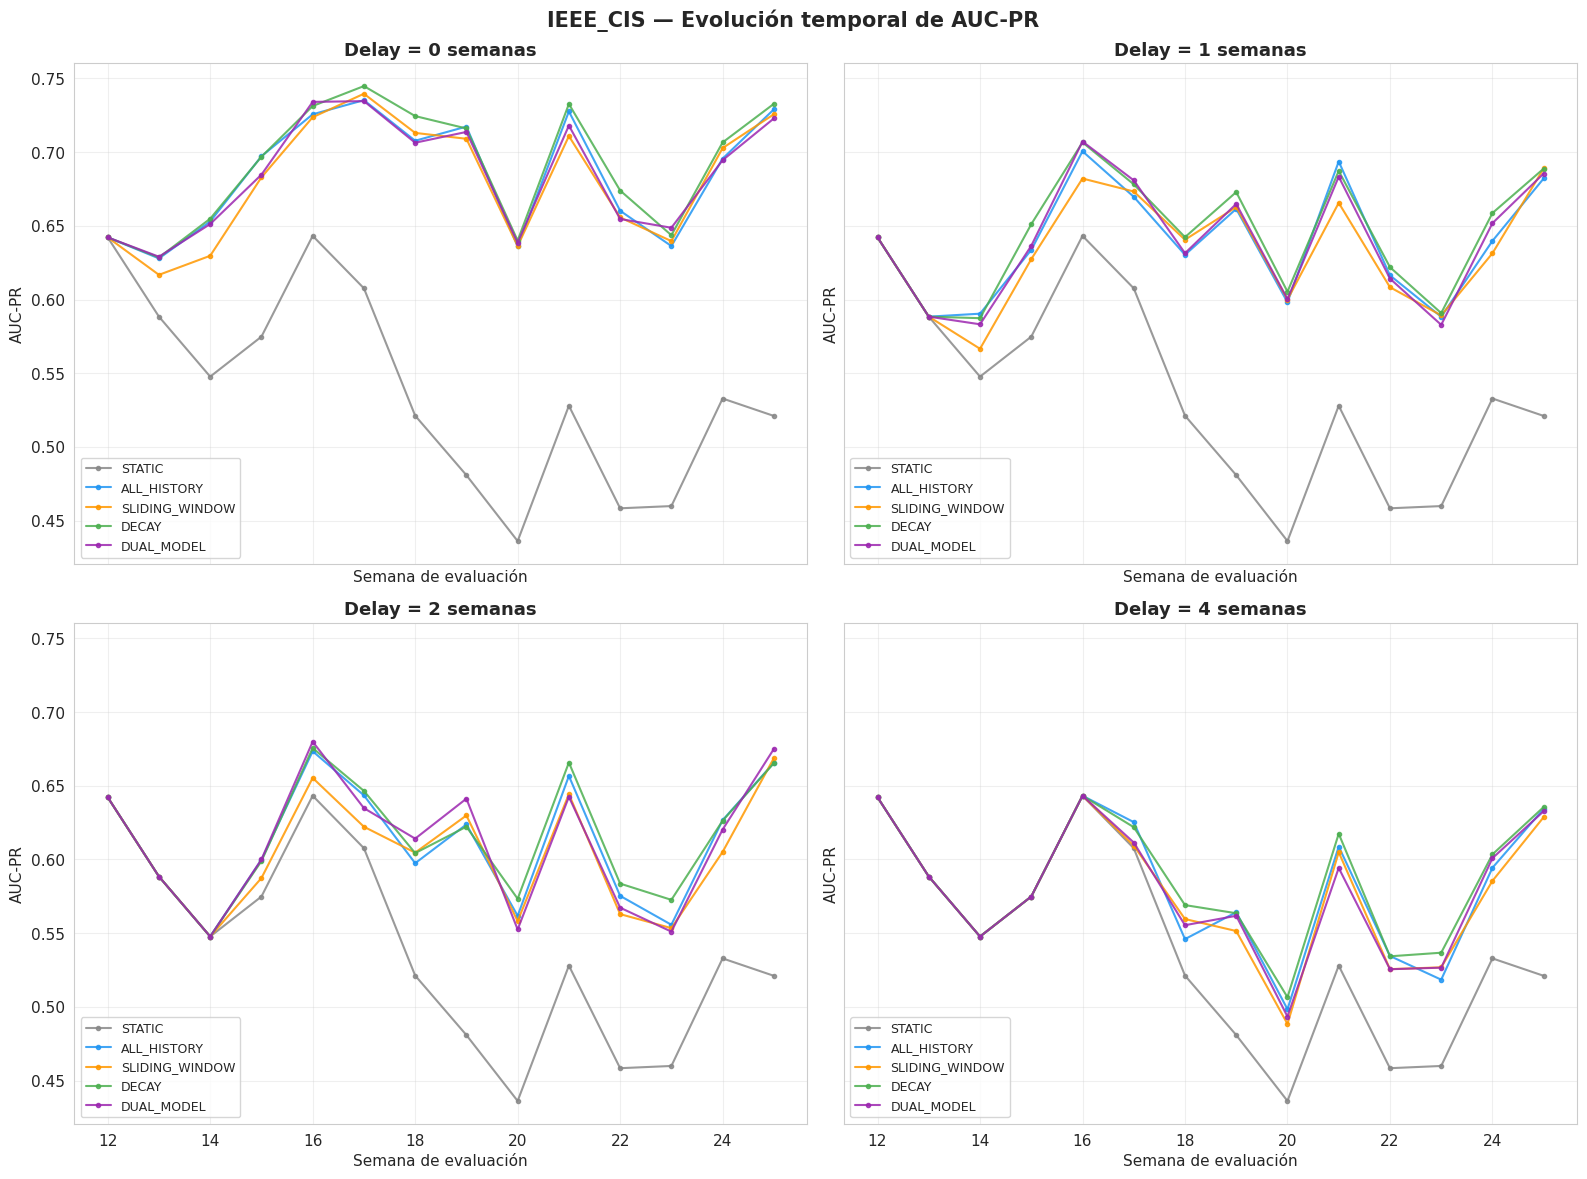

Guardado: temporal_evolution_auc_pr.png


In [31]:
# =============================================================================
# 5.2 Visualización: Evolución temporal de AUC-PR por strategy × delay
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

strategy_colors = {
    'STATIC': '#888888',
    'ALL_HISTORY': '#2196F3',
    'SLIDING_WINDOW': '#FF9800',
    'DECAY': '#4CAF50',
    'DUAL_MODEL': '#9C27B0'
}

for idx, delay in enumerate(DELAY_SCENARIOS):
    ax = axes[idx]
    sub = df_results[df_results['delay'] == delay]
    
    for strategy in STRATEGIES:
        data = sub[sub['strategy'] == strategy]
        ax.plot(
            data['eval_period'], data['auc_pr'],
            marker='o', markersize=3, linewidth=1.5,
            color=strategy_colors[strategy],
            label=strategy, alpha=0.85
        )
    
    ax.set_title(f'Delay = {delay} semanas', fontsize=13, fontweight='bold')
    ax.set_xlabel('Semana de evaluación')
    ax.set_ylabel('AUC-PR')
    ax.legend(loc='lower left', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'{DATASET_NAME} — Evolución temporal de AUC-PR', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'temporal_evolution_auc_pr.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: temporal_evolution_auc_pr.png")

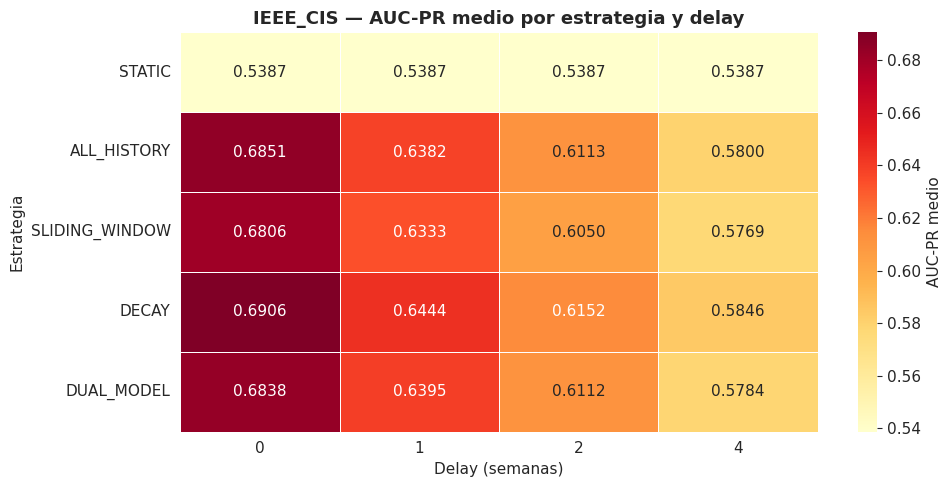

Guardado: heatmap_auc_pr.png


In [32]:
# =============================================================================
# 5.3 Visualización: Heatmap de AUC-PR media (strategy × delay)
# =============================================================================

pivot = summary.pivot(index='strategy', columns='delay', values='auc_pr_mean')
# Reordenar estrategias
pivot = pivot.reindex(STRATEGIES)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot, annot=True, fmt='.4f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'AUC-PR medio'}
)
ax.set_title(f'{DATASET_NAME} — AUC-PR medio por estrategia y delay', fontsize=13, fontweight='bold')
ax.set_xlabel('Delay (semanas)')
ax.set_ylabel('Estrategia')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'heatmap_auc_pr.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: heatmap_auc_pr.png")

In [33]:
# =============================================================================
# 5.4 Deltas respecto a ALL_HISTORY (preview para NB_04)
# =============================================================================

# Calcular deltas: strategy - ALL_HISTORY por período y delay
all_hist = df_results[df_results['strategy'] == 'ALL_HISTORY'][
    ['delay', 'eval_period', 'auc_pr']
].rename(columns={'auc_pr': 'auc_pr_baseline'})

df_deltas = df_results.merge(all_hist, on=['delay', 'eval_period'], how='left')
df_deltas['delta_auc_pr'] = df_deltas['auc_pr'] - df_deltas['auc_pr_baseline']

# Resumen de deltas por estrategia adaptativa
adaptive = df_deltas[~df_deltas['strategy'].isin(['ALL_HISTORY', 'STATIC'])]

print("=" * 70)
print("DELTAS vs ALL_HISTORY (AUC-PR) — Preview")
print("=" * 70)
delta_summary = adaptive.groupby(['strategy', 'delay']).agg(
    delta_mean=('delta_auc_pr', 'mean'),
    delta_median=('delta_auc_pr', 'median'),
    delta_std=('delta_auc_pr', 'std'),
    pct_positive=('delta_auc_pr', lambda x: (x > 0).mean())
).reset_index()

for delay in DELAY_SCENARIOS:
    print(f"\n  Delay = {delay} semanas:")
    sub = delta_summary[delta_summary['delay'] == delay]
    for _, row in sub.iterrows():
        sign = '+' if row['delta_mean'] >= 0 else ''
        print(f"    {row['strategy']:20s}  Δ mean: {sign}{row['delta_mean']:.5f}  "
              f"median: {sign}{row['delta_median']:.5f}  "
              f"% positivo: {row['pct_positive']:.0%}")

print("\n\nNota: el análisis estadístico formal (Friedman, Wilcoxon, Cliff's Delta)")
print("se realiza en NB_04 con los datos de los 3 datasets.")

DELTAS vs ALL_HISTORY (AUC-PR) — Preview

  Delay = 0 semanas:
    DECAY                 Δ mean: +0.00554  median: +0.00446  % positivo: 79%
    DUAL_MODEL            Δ mean: -0.00127  median: -0.00120  % positivo: 29%
    SLIDING_WINDOW        Δ mean: -0.00451  median: -0.00266  % positivo: 36%

  Delay = 1 semanas:
    DECAY                 Δ mean: +0.00619  median: +0.00635  % positivo: 71%
    DUAL_MODEL            Δ mean: +0.00124  median: +0.00163  % positivo: 57%
    SLIDING_WINDOW        Δ mean: -0.00489  median: 0.00000  % positivo: 43%

  Delay = 2 semanas:
    DECAY                 Δ mean: +0.00392  median: +0.00107  % positivo: 50%
    DUAL_MODEL            Δ mean: -0.00005  median: 0.00000  % positivo: 36%
    SLIDING_WINDOW        Δ mean: -0.00626  median: -0.00294  % positivo: 21%

  Delay = 4 semanas:
    DECAY                 Δ mean: +0.00459  median: +0.00000  % positivo: 43%
    DUAL_MODEL            Δ mean: -0.00158  median: 0.00000  % positivo: 21%
    SLIDING_WIND

In [36]:
# =============================================================================
# 5.5 Resumen final del notebook
# =============================================================================

print("=" * 70)
print(f"NB_01 — {DATASET_NAME}: COMPLETADO")
print("=" * 70)
print(f"\nArchivos generados en {RESULTS_DIR}/:")

output_files = [
    'period_validation.csv',
    'feature_exclusion_log.json',
    'features_final.json',
    'best_params.json',
    'optuna_history.csv',
    'experiment_results.csv',
    'experiment_summary.csv',
    'temporal_evolution_auc_pr.png',
    'heatmap_auc_pr.png'
]

for f_name in output_files:
    fpath = os.path.join(RESULTS_DIR, f_name)
    exists = '✓' if os.path.exists(fpath) else '✗'
    print(f"  {exists} {f_name}")

print(f"\nDataset: {df.shape[0]:,} filas, {len(features_final)} features")
print(f"Configuración: {len(STRATEGIES)} estrategias × {len(DELAY_SCENARIOS)} delays × {len(EVAL_WEEKS)} períodos")
print(f"Total resultados: {len(df_results)} filas en experiment_results.csv")

NB_01 — IEEE_CIS: COMPLETADO

Archivos generados en ./results/ieee_cis/:
  ✓ period_validation.csv
  ✓ feature_exclusion_log.json
  ✓ features_final.json
  ✓ best_params.json
  ✓ optuna_history.csv
  ✓ experiment_results.csv
  ✓ experiment_summary.csv
  ✓ temporal_evolution_auc_pr.png
  ✓ heatmap_auc_pr.png

Dataset: 590,540 filas, 319 features
Configuración: 5 estrategias × 4 delays × 14 períodos
Total resultados: 280 filas en experiment_results.csv
